# NYC taxi flows: Monty aggregates real trips, three.js renders a glowing flow map

An agent asked for "where does the taxi traffic actually go, and when" writes two programs,
because each language has a job it is good at:

* **Python, in Monty** (pydantic's Python sandbox): the numbers. It joins 60,000 real sampled
  NYC Yellow Taxi trips (`vendor/data/nyc_taxi_trips_2025-01_sample.csv`) against the 263 taxi
  zones (`vendor/data/nyc_taxi_zones.csv`) -- see `vendor/data/README.md` for full provenance --
  bins pickups by hour-of-day into four buckets (morning/midday/evening/night), and aggregates
  every origin-destination zone pair into a flow (trip count, mean fare, mean duration, the
  dominant time bucket). Monty's sandbox cannot read your filesystem or import `csv`/`pyarrow`,
  so the HOST reads both CSVs and hands Monty plain lists; Monty does the join and aggregation in
  pure Python.
* **JavaScript, in pydeno** (a worker process behind an OS sandbox): the picture. three.js
  projects every zone onto a flat local plane, extrudes a density column per zone, and draws the
  busiest flows as glowing tapered arcs between pickup and dropoff -- a comet-trail gradient
  along each tube, plus a fatter, dimmer, additively-blended twin underneath to fake a bloom
  halo. Exports a binary glTF (`.glb`).

**Why Arrow IPC, not JSON:** pyarrow is not available inside Monty, so the `pa.Table` is built
HOST-side from Monty's JSON-safe result, then shipped into the pydeno sandbox as Arrow IPC bytes
-- the same pattern as `examples/arrow_ipc_dataframes.py`. The flow table lands at 5,415 distinct
origin-destination pairs out of 60,000 sampled trips, almost exactly the ~5,000-row crossover that
example measured; see the module docstring in `examples/monty_taxi_flows.py` for the numbers
re-measured against this script's own schema.

Both halves run without trusting either: neither can touch your files, network or environment
beyond the host functions handed to them.

In [1]:
from __future__ import annotations

import asyncio
import csv
import pathlib
import time
from typing import Any

import pyarrow as pa

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig
from pydantic_monty import Monty

The script calls `asyncio.run()` inside `TaxiFlowsPipeline.render`; a Jupyter kernel already
runs its own event loop, so that call needs `nest_asyncio` patched in first. This cell has no
equivalent in the script -- it exists only because a notebook kernel is async where a plain
script process is not.

In [2]:
import nest_asyncio

nest_asyncio.apply()

Paths are relative to the repo root, not to `__file__` as in the script version. This helper
walks up from the current directory to find the checkout, so it works whether the kernel's
working directory is the repo root (running from the command line) or `examples/notebooks/`
(opening the notebook directly in Jupyter).

In [3]:
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


REPO_ROOT = _repo_root()
LIBS = REPO_ROOT / "vendor" / "libs"
DATA = REPO_ROOT / "vendor" / "data"
THREE_BUNDLE = "three-0.180.0-gltf.bundle.js"
ARROW_BUNDLE = "apache-arrow-21.2.0.es2015.min.js"
TRIPS_CSV = DATA / "nyc_taxi_trips_2025-01_sample.csv"
ZONES_CSV = DATA / "nyc_taxi_zones.csv"
assert (LIBS / THREE_BUNDLE).exists(), "run this notebook with cwd inside a pydeno checkout"
assert TRIPS_CSV.exists(), "run this notebook with cwd inside a pydeno checkout"
print(f"repo root: {REPO_ROOT}")

repo root: /Users/dominikpeter/DevOps/pydeno/.claude/worktrees/agent-a6fb218c937cafd37


Host side: read the vendored CSVs. Monty cannot do this itself -- no filesystem, no `csv`
module inside it (both checked directly against a session: `import csv` raises
`ModuleNotFoundError`).

In [4]:
def load_zones() -> list[list[Any]]:
    """``[location_id, borough, zone, lon, lat]`` per taxi zone."""
    with ZONES_CSV.open(newline="") as f:
        return [
            [
                int(row["location_id"]),
                row["borough"],
                row["zone"],
                float(row["lon"]),
                float(row["lat"]),
            ]
            for row in csv.DictReader(f)
        ]


def load_trips() -> list[list[Any]]:
    """One row per sampled trip, in the CSV's own column order."""
    with TRIPS_CSV.open(newline="") as f:
        return [
            [
                row["tpep_pickup_datetime"],
                row["tpep_dropoff_datetime"],
                int(float(row["passenger_count"])),
                float(row["trip_distance"]),
                int(row["PULocationID"]),
                int(row["DOLocationID"]),
                row["payment_type"],
                float(row["fare_amount"]),
                float(row["tip_amount"]),
                float(row["total_amount"]),
            ]
            for row in csv.DictReader(f)
        ]


zones_rows = load_zones()
trips_rows = load_trips()
print(f"{len(zones_rows)} zones, {len(trips_rows)} trips")

263 zones, 60000 trips


The Python half (what the model wrote). It runs in Monty: `datetime` only, no files, no
`csv`.

In [5]:
MODEL_PYTHON = """
import datetime


def bucket_of(hour):
    # 0 morning, 1 midday, 2 evening, 3 night -- matches the JS palette order.
    if 5 <= hour < 11:
        return 0
    if 11 <= hour < 17:
        return 1
    if 17 <= hour < 21:
        return 2
    return 3


zone_by_id = {}
for loc_id, borough, zone_name, lon, lat in ZONES:
    zone_by_id[loc_id] = (lon, lat, borough, zone_name)

zone_density = {}
flow_counts = {}
skipped = 0

for trip in TRIPS:
    pu_t, do_t, passengers, dist, pu, do, pay, fare, tip, total = trip
    if pu not in zone_by_id or do not in zone_by_id:
        skipped += 1
        continue
    pu_dt = datetime.datetime.strptime(pu_t, "%Y-%m-%d %H:%M:%S")
    do_dt = datetime.datetime.strptime(do_t, "%Y-%m-%d %H:%M:%S")
    dur_min = (do_dt - pu_dt).total_seconds() / 60.0
    if dur_min <= 0 or dur_min > 240:
        skipped += 1
        continue
    b = bucket_of(pu_dt.hour)

    zd = zone_density.setdefault(pu, [0, 0, 0, 0, 0])
    zd[0] += 1
    zd[1 + b] += 1

    key = (pu, do)
    fl = flow_counts.setdefault(key, [0, 0.0, 0.0, [0, 0, 0, 0]])
    fl[0] += 1
    fl[1] += fare
    fl[2] += dur_min
    fl[3][b] += 1

zones_out = []
for loc_id, counts in zone_density.items():
    lon, lat, borough, name = zone_by_id[loc_id]
    zones_out.append(
        [loc_id, lon, lat, borough, name, counts[0], counts[1], counts[2], counts[3], counts[4]]
    )

flows_out = []
for (pu, do), fl in flow_counts.items():
    pu_lon, pu_lat, _, _ = zone_by_id[pu]
    do_lon, do_lat, _, _ = zone_by_id[do]
    count = fl[0]
    dominant = fl[3].index(max(fl[3]))
    flows_out.append(
        [
            pu, do, pu_lon, pu_lat, do_lon, do_lat, count,
            fl[1] / count, fl[2] / count, dominant,
        ]
    )
flows_out.sort(key=lambda r: -r[6])

{
    "zones": zones_out,
    "flows": flows_out,
    "trip_count": len(TRIPS),
    "zone_count": len(zones_out),
    "flow_count": len(flows_out),
    "skipped": skipped,
}
"""

ZONE_COLUMNS = ('location_id', 'lon', 'lat', 'borough', 'zone', 'pickups', 'morning', 'midday', 'evening', 'night')
FLOW_COLUMNS = ('pu_id', 'do_id', 'pu_lon', 'pu_lat', 'do_lon', 'do_lat', 'trip_count', 'mean_fare', 'mean_duration_min', 'dominant_bucket')


def rows_to_table(rows: list[list[Any]], columns: tuple[str, ...]) -> pa.Table:
    return pa.Table.from_pylist([dict(zip(columns, row, strict=True)) for row in rows])


def to_ipc(table: pa.Table) -> bytes:
    """Serialize an Arrow table to a self-describing IPC stream."""
    sink = pa.BufferOutputStream()
    with pa.ipc.new_stream(sink, table.schema) as writer:
        writer.write_table(table)
    return sink.getvalue().to_pybytes()


The JavaScript half. It runs in pydeno with three.js and apache-arrow loaded; `getZonesIpc()`
and `getFlowsIpc()` are the host functions that hand it Monty's result as Arrow IPC bytes.

In [6]:
MODEL_JAVASCRIPT = """
globalThis.buildScene = (topFlows) => {
  const zones = Arrow.tableFromIPC(getZonesIpc());
  const flows = Arrow.tableFromIPC(getFlowsIpc());

  // Local equirectangular-ish projection centred on the data's own bounding box (same trick as
  // monty_turf_geo.py's SVG map, just onto an X/Z plane instead of X/Y pixels).
  const lonCol = zones.getChild('lon'), latCol = zones.getChild('lat');
  let lon0 = Infinity, lon1 = -Infinity, lat0 = Infinity, lat1 = -Infinity;
  for (let i = 0; i < zones.numRows; i++) {
    const lo = lonCol.get(i), la = latCol.get(i);
    lon0 = Math.min(lon0, lo); lon1 = Math.max(lon1, lo);
    lat0 = Math.min(lat0, la); lat1 = Math.max(lat1, la);
  }
  const midLat = (lat0 + lat1) / 2;
  const kx = Math.cos((midLat * Math.PI) / 180);
  const SPAN = 140; // world units across the longer axis
  const scale = SPAN / Math.max((lon1 - lon0) * kx, lat1 - lat0);
  const project = (lo, la) => [
    (lo - (lon0 + lon1) / 2) * kx * scale,
    -(la - midLat) * scale, // north is -Z, so the map reads the right way up from above
  ];

  const scene = new THREE.Scene();

  // Dark "night city" ground plane.
  const groundSize = SPAN * 1.3;
  const ground = new THREE.Mesh(
    new THREE.PlaneGeometry(groundSize, groundSize),
    new THREE.MeshStandardMaterial({ color: 0x050811, roughness: 1, metalness: 0 }),
  );
  ground.rotateX(-Math.PI / 2);
  scene.add(ground);

  // Density columns: one InstancedMesh box per zone, height and colour by pickup count (log
  // scale -- Manhattan zones outnumber the rest by 2-3 orders of magnitude).
  const pickups = zones.getChild('pickups');
  let maxLog = 0;
  for (let i = 0; i < zones.numRows; i++) maxLog = Math.max(maxLog, Math.log1p(Number(pickups.get(i))));
  const cold = [0.10, 0.65, 0.85];  // cyan: quiet zone
  const hot = [1.00, 0.70, 0.15];   // amber: busy zone
  const lerp3 = (a, b, t) => [a[0] + (b[0] - a[0]) * t, a[1] + (b[1] - a[1]) * t, a[2] + (b[2] - a[2]) * t];

  const boxGeo = new THREE.BoxGeometry(1, 1, 1);
  const columns = new THREE.InstancedMesh(
    boxGeo,
    new THREE.MeshStandardMaterial({
      vertexColors: true,
      emissive: 0x332211,
      emissiveIntensity: 0.9,
      roughness: 0.45,
      metalness: 0.1,
    }),
    zones.numRows,
  );
  const colors = new Float32Array(zones.numRows * 3);
  const m = new THREE.Matrix4();
  const footprint = scale * 0.0035; // degrees -> world units, shrunk so columns don't overlap
  let totalPickups = 0;
  for (let i = 0; i < zones.numRows; i++) {
    const n = Number(pickups.get(i));
    totalPickups += n;
    const t = Math.log1p(n) / (maxLog || 1);
    const height = 0.6 + t * 22;
    const [x, z] = project(lonCol.get(i), latCol.get(i));
    m.makeScale(footprint, height, footprint);
    m.setPosition(x, height / 2, z);
    columns.setMatrixAt(i, m);
    colors.set(lerp3(cold, hot, t), i * 3);
  }
  columns.instanceColor = new THREE.InstancedBufferAttribute(colors, 3);
  scene.add(columns);

  // Flow arcs: the busiest `topFlows` origin-destination pairs, lifted into bezier-ish arcs
  // (CatmullRomCurve3 through a raised midpoint, like a flight path) and swept with a tapered,
  // colour-graded TubeGeometry -- bright near the pickup end, fading toward the dropoff end. A
  // second, fatter, dimmer, additively-blended tube underneath fakes a bloom halo; the vendored
  // bundle has no postprocessing pass, so this is the whole glow budget.
  const bucketColor = [
    [1.00, 0.55, 0.15], // morning: amber
    [0.15, 0.95, 0.75], // midday: cyan
    [0.95, 0.20, 0.75], // evening: magenta
    [0.25, 0.35, 1.00], // night: blue
  ];
  const puId = flows.getChild('pu_id'), doId = flows.getChild('do_id');
  const puLon = flows.getChild('pu_lon'), puLat = flows.getChild('pu_lat');
  const doLon = flows.getChild('do_lon'), doLat = flows.getChild('do_lat');
  const tripCount = flows.getChild('trip_count'), dominant = flows.getChild('dominant_bucket');
  const n = Math.min(topFlows, flows.numRows);
  let maxCount = 0;
  for (let i = 0; i < n; i++) maxCount = Math.max(maxCount, Number(tripCount.get(i)));

  const arcGroup = new THREE.Group();
  const flowStats = [];
  for (let i = 0; i < n; i++) {
    const [ax, az] = project(puLon.get(i), puLat.get(i));
    const [bx, bz] = project(doLon.get(i), doLat.get(i));
    const planar = Math.hypot(bx - ax, bz - az);
    const weight = Number(tripCount.get(i)) / (maxCount || 1);
    // Lift clears the tallest density column (up to ~23 units) so arcs read above the skyline
    // instead of disappearing into it; rank-based (i / n) rather than raw weight, so even the
    // tail of `topFlows` still arcs clear.
    const lift = 20 + planar * 0.4 + (1 - i / n) * 22;
    const mid = new THREE.Vector3((ax + bx) / 2, lift, (az + bz) / 2);
    const start = new THREE.Vector3(ax, 1.2, az);
    const end = new THREE.Vector3(bx, 1.2, bz);
    const curve = new THREE.CatmullRomCurve3([start, mid, end]);

    const samples = 48;
    const radial = 6;
    const baseRadius = 0.15 + weight * 0.55;
    const color = bucketColor[Number(dominant.get(i))];

    const buildTube = (radiusScale, opacity, blending) => {
      const tube = new THREE.TubeGeometry(curve, samples, baseRadius * radiusScale, radial, false);
      const pos = tube.attributes.position;
      const ringCount = pos.count / (radial + 1);
      const cols = new Float32Array(pos.count * 3);
      for (let k = 0; k < pos.count; k++) {
        const ring = Math.floor(k / (radial + 1));
        const u = ring / (ringCount - 1); // 0 at pickup, 1 at dropoff
        const fade = 1 - u; // bright at pickup, fading toward dropoff
        cols.set([color[0] * fade, color[1] * fade, color[2] * fade], k * 3);
      }
      tube.setAttribute('color', new THREE.BufferAttribute(cols, 3));
      const mat = new THREE.MeshBasicMaterial({
        vertexColors: true, transparent: true, opacity, blending, depthWrite: false,
      });
      return new THREE.Mesh(tube, mat);
    };

    arcGroup.add(buildTube(2.6, 0.18, THREE.AdditiveBlending)); // glow halo
    arcGroup.add(buildTube(1.0, 0.95, THREE.NormalBlending));   // core
    flowStats.push({
      pu: Number(puId.get(i)), do: Number(doId.get(i)), tripCount: Number(tripCount.get(i)),
      meanFare: flows.getChild('mean_fare').get(i),
      meanDurationMin: flows.getChild('mean_duration_min').get(i),
      dominantBucket: Number(dominant.get(i)), lift,
    });
  }
  scene.add(arcGroup);

  scene.add(new THREE.AmbientLight(0x8fa0dd, 1.8));
  const key = new THREE.PointLight(0xfff2cc, 2.4, 0, 1.5);
  key.position.set(0, 70, 20);
  scene.add(key);
  const fill = new THREE.PointLight(0x5ec9ff, 1.4, 0, 1.5);
  fill.position.set(-50, 40, -40);
  scene.add(fill);

  scene.updateMatrixWorld(true);
  globalThis.__scene = scene;

  const box = new THREE.Box3().setFromObject(scene);
  return {
    zones: zones.numRows,
    flowsDrawn: n,
    flowsTotal: flows.numRows,
    totalPickups,
    bounds: [box.min.toArray(), box.max.toArray()],
    flowStats,
  };
};

globalThis.exportGlb = () => new Promise((resolve, reject) =>
  new GLTFExporter().parse(globalThis.__scene, resolve, reject, { binary: true }));
"""

One Monty pool and one warm pydeno runtime, reused across renders.

In [7]:
DEFAULT_TOP_FLOWS = 50


class TaxiFlowsPipeline:
    """One Monty pool and one warm pydeno runtime, reused across renders."""

    def __init__(self, *, jitless: bool = True) -> None:
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        self._zones_ipc = b""
        self._flows_ipc = b""
        self.rt.bind_function("getZonesIpc", lambda: self._zones_ipc)
        self.rt.bind_function("getFlowsIpc", lambda: self._flows_ipc)
        self.load_seconds = 0.0
        self._zones_rows = load_zones()
        self._trips_rows = load_trips()

    def load_libraries(self) -> None:
        start = time.perf_counter()
        self.rt.eval((LIBS / ARROW_BUNDLE).read_text() + "\n;0")
        self.rt.eval((LIBS / THREE_BUNDLE).read_text() + "\n;0")
        self.rt.eval(MODEL_JAVASCRIPT + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def prepare(self) -> dict[str, Any]:
        """Python half, in Monty: real trips joined to zones, binned and aggregated."""
        with self.monty.checkout() as session:
            return session.feed_run(
                MODEL_PYTHON,
                inputs={"ZONES": self._zones_rows, "TRIPS": self._trips_rows},
            )

    def render(
        self, top_flows: int = DEFAULT_TOP_FLOWS
    ) -> tuple[bytes, dict[str, Any], dict[str, Any], dict[str, float]]:
        t0 = time.perf_counter()
        analysis = self.prepare()
        zones_table = rows_to_table(analysis["zones"], ZONE_COLUMNS)
        flows_table = rows_to_table(analysis["flows"], FLOW_COLUMNS)
        self._zones_ipc = to_ipc(zones_table)
        self._flows_ipc = to_ipc(flows_table)
        t1 = time.perf_counter()
        stats = self.rt.eval(f"buildScene({top_flows})")
        t2 = time.perf_counter()
        glb = asyncio.run(self.rt.eval_async("exportGlb()", timeout=300))
        t3 = time.perf_counter()
        meta = {
            "trip_count": analysis["trip_count"],
            "skipped": analysis["skipped"],
            "zone_count": analysis["zone_count"],
            "flow_count": analysis["flow_count"],
            "zones_ipc_bytes": len(self._zones_ipc),
            "flows_ipc_bytes": len(self._flows_ipc),
        }
        timings = {
            "monty_prepare": t1 - t0,
            "three_build": t2 - t1,
            "glb_export": t3 - t2,
            "total": t3 - t0,
        }
        return bytes(glb), stats, meta, timings

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)


Run it: load three.js and apache-arrow into the sandbox, join and aggregate the real trips in
Monty, build the scene and export the `.glb` in pydeno.

In [8]:
pipe = TaxiFlowsPipeline()
try:
    print(f"sandbox: {pipe.rt.sandbox}")
    pipe.load_libraries()
    print(f"three.js + apache-arrow loaded into the sandbox in {pipe.load_seconds * 1000:.0f} ms")
    glb, stats, meta, t = pipe.render(50)
    pathlib.Path("taxi_flows.glb").write_bytes(glb)
    print(
        f"{meta['trip_count']} trips -> {meta['zone_count']} zones with pickups, "
        f"{meta['flow_count']} distinct origin-destination pairs "
        f"({meta['skipped']} trips skipped: unknown zone or bad duration)"
    )
    print(
        f"  Arrow IPC: zones {meta['zones_ipc_bytes'] / 1024:.1f} KiB, "
        f"flows {meta['flows_ipc_bytes'] / 1024:.1f} KiB"
    )
    print(
        f"  scene: {stats['zones']} density columns, "
        f"{stats['flowsDrawn']} of {stats['flowsTotal']} flows drawn as arcs, "
        f"{stats['totalPickups']} total pickups"
    )
    print(f"  monty joined + aggregated   {t['monty_prepare'] * 1000:8.0f} ms")
    print(f"  three.js built the scene    {t['three_build'] * 1000:8.0f} ms")
    print(f"  glTF export                 {t['glb_export'] * 1000:8.0f} ms")
    print(f"wrote taxi_flows.glb ({len(glb) / 1024:.0f} KiB) in {t['total'] * 1000:.0f} ms total")
finally:
    pipe.close()

sandbox: seatbelt
three.js + apache-arrow loaded into the sandbox in 51 ms


60000 trips -> 204 zones with pickups, 5415 distinct origin-destination pairs (56 trips skipped: unknown zone or bad duration)
  Arrow IPC: zones 20.0 KiB, flows 424.2 KiB
  scene: 204 density columns, 50 of 5415 flows drawn as arcs, 59944 total pickups
  monty joined + aggregated        471 ms
  three.js built the scene         175 ms
  glTF export                      321 ms
wrote taxi_flows.glb (1963 KiB) in 966 ms total


The `.glb` is a binary glTF scene; it isn't rendered inline here. Below: confirm it was
written, then show the pre-rendered preview used in the docs gallery (a headless-Chromium
screenshot of the same scene, built from this script's own `MODEL_JAVASCRIPT`).

In [9]:
glb_path = pathlib.Path("taxi_flows.glb")
assert glb_path.exists(), "taxi_flows.glb was not written"
glb_size = glb_path.stat().st_size
print(f"wrote {glb_path} ({glb_size} bytes, {glb_size / 1024:.1f} KiB)")

wrote taxi_flows.glb (2010048 bytes, 1962.9 KiB)


Glowing amber/cyan/magenta flow arcs rising above a dark grid of density columns, busiest
origin-destination pairs lifted highest.

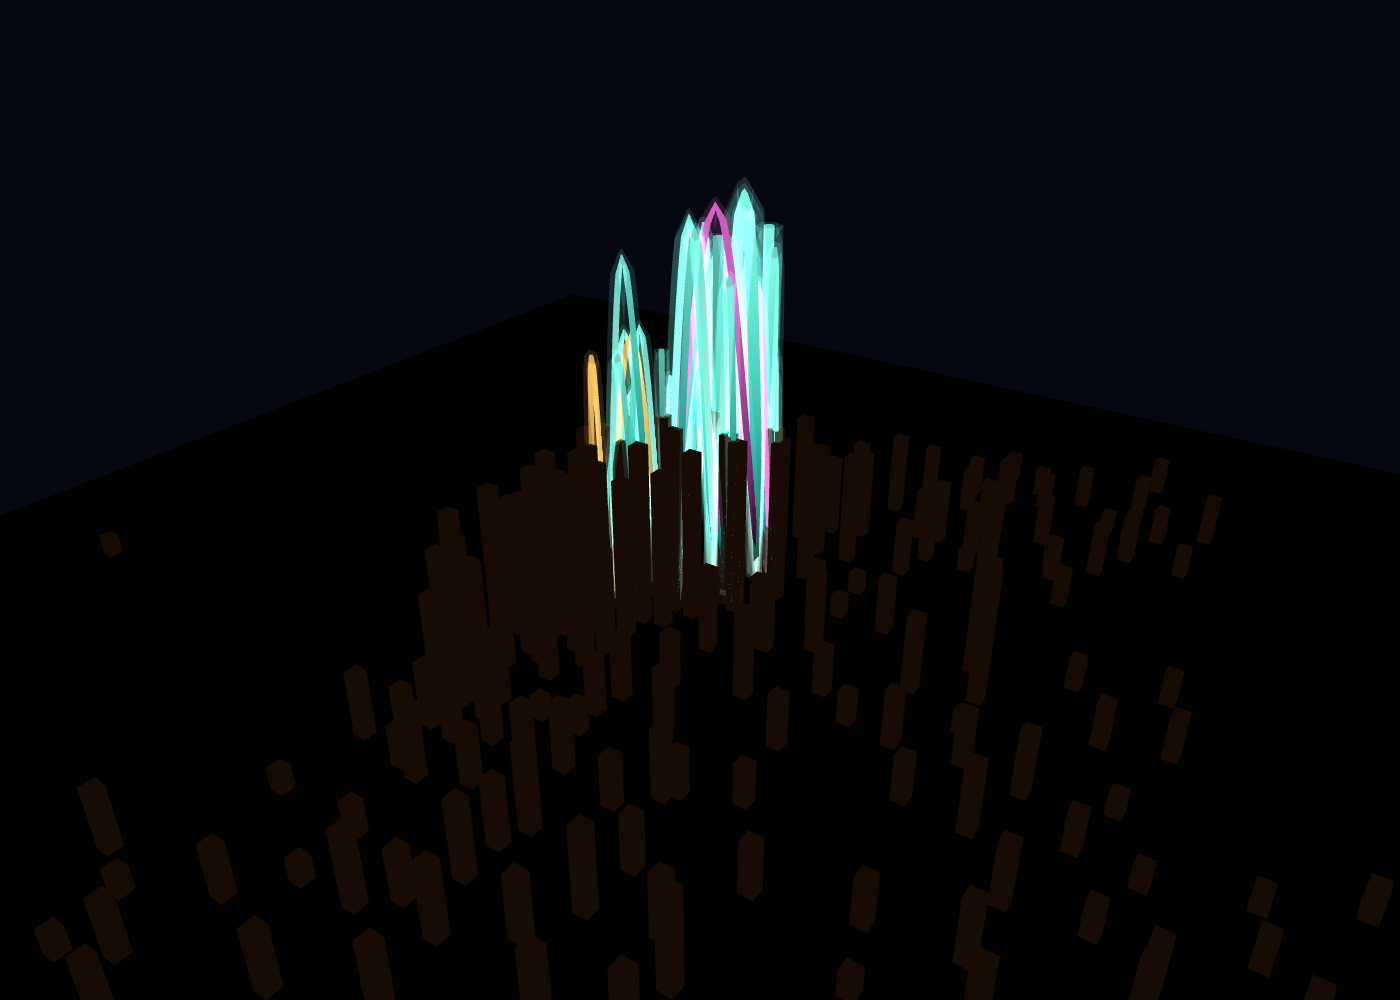

In [10]:
from IPython.display import Image, display

display(Image(filename=str(REPO_ROOT / "docs" / "assets" / "examples" / "monty_taxi_flows.png")))